In [1]:
import cv2
import time
import re
import base64
import json
import io
import os
import traceback
import numpy as np 
import robotic as ry
import matplotlib.pyplot as plt
from PIL import Image
from dotenv import load_dotenv
from openai import OpenAI

from pathlib import Path
from datetime import datetime

from WayTu_RAI.GenerateEnvironment import GenerateEnvironment, PlacementError
import WayTu_RAI.model_utils as mutils

load_dotenv()  # loads OPENAI_API_KEY from .env
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY")) 

ry.params_add({'physx/motorKp': 10000., 
               'physx/motorK  d': 1000., 
               'physx/angularDamping': 10., 
               'physx/defaultFriction': 1000.})

ry.params_add({'botsim/engine': 'physx'})
ry.params_add({'physx/multibody': True})
ry.params_print()

print(ry.__version__)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
0.1.10physx/motorKp: 10000,
physx/motorK  d: 1000,
physx/angularDamping: 10,
physx/defaultFriction: 1000,
botsim/engine: physx,
physx/multibody


In [2]:
parameters = {
    "num-trials"        : 1,
    "num-tools"         : 3,
    "tool-type"         : 'primitive',
    "task"              : 'hammering',
    "mode"              : 'test',
    "area-middle"       : { "min": [-0.35 , 0.15, 0.060], "max": [ 0.35 , 0.45, 0.065] },
    "area-negative"     : { "min": [-0.50 , 0.15, 0.050], "max": [ -0.35 , 0.45, 0.060] },
    "area-positive"     : { "min": [0.40 , 0.15, 0.050], "max": [ 0.50 , 0.45, 0.060] },
    "label-list-all"    : ["lifting-platform", "minigolf-platform", "hammering-platform", "hammer", "spatula", "L-ruler", "screwdriver", "ball", "book", "thin-stick", "ring"],
    "cameras"           : ["camera5"],
}

In [3]:
def draw_rgb_and_depth(rgb, depth):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb)
    plt.title("RGB")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(depth)
    plt.title("Depth")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def numpy_to_bytes(numpy_image_array, target_size=(336, 336)):
    resized_array = cv2.resize(numpy_image_array, target_size, interpolation=cv2.INTER_AREA)

    if resized_array.dtype != 'uint8':
        resized_array = resized_array.astype('uint8')

    pil_img = Image.fromarray(resized_array)
    byte_stream = io.BytesIO()
    pil_img.save(byte_stream, format='JPEG')
    return byte_stream.getvalue()

In [4]:
# Camera Roles:
# Front angled view of the robotic workspace, showing the robot, tools, and task objects from an oblique perspective.

In [5]:
def get_prompt_detailed(task_name, task_desc):
    return f"""You are an expert spatial reasoning model.
You are provided with a 500x500 pixel image view of a robotic workspace.

TASK: {task_name}
TASK DESCRIPTION: {task_desc} 

Because the workspace layout is randomized, you must use the following spatial logic to determine your coordinates:

Scene Identification: Locate the tools and the target object (e.g., a nail or peg) protruding from a vertical surface.

    1. Tool Selection Logic: Select the tool with the appropriate mass and striking surface for horizontal force.
       - **Reasoning**: Explain why the tool's shape allows for a clean strike on a horizontal target.

    2. Interaction Logic: Mentally determine the striking path. The tool must move from a "ready" position in front of the target to an "impact" position flush with the vertical surface.

    3. Tool Waypoint (Grasp): Identify the graspable handle of your chosen tool. 
      - The Tool Waypoint [u, v] MUST fall directly on the pixels of the tool's handle.
      - NEGATIVE CONSTRAINT: The Tool Waypoint must NOT be on the grey floor.

    4. Initial Waypoint (Setup): Identify the head of the protruding target. 
       - **CRITICAL**: The Initial Waypoint is the "Ready-to-Strike" position. Place this pixel a few pixels away from the target's head, aligned perfectly with the target's horizontal axis.

    5. Goal Waypoint (Impact): This represents the moment of full insertion. From the Initial Waypoint, move the pixel coordinate along the target's axis toward the vertical wall until it aligns with the impact surface. Maintain a consistent 'v' value to ensure the strike is level.

Look at the camera view and do all of the following together:
    - Select ONE tool from ["hammer", "L-ruler", "spatula"].
    - Provide a brief explanation of the tool's mechanical advantage for this strike.
    - Identify the [u, v] coordinates for Tool, Initial, and Goal Waypoints.

Definitions:
    Tool Waypoint: Where the robot gripper grasps the tool handle.
    Initial Waypoint: The tool's head hovering in front of the target, aligned for a horizontal strike.
    Goal Waypoint: The tool's head as it drives the target into the vertical surface.

Important:
    - The Goal Waypoint must be closer to the vertical wall than the Initial Waypoint.
    - Both Initial and Goal waypoints must maintain a nearly identical 'v' value to ensure the tool does not slip off the target's axis.

Output ONLY a JSON dictionary matching this exact structure. Do not use markdown:
{{
  "selected_tool": "<hammer, L-ruler, or spatula>",
  "selection_reasoning": "<1-2 sentences explaining why this tool fits the requirement for a horizontal strike>",
  "tool_waypoint": {{
    "camera_uv": [u, v]
  }},
  "initial_waypoint": {{
    "camera_uv": [u, v]
  }},
  "goal_waypoint": {{
    "camera_uv": [u, v]
  }}
}}

Begin your JSON response now:"""

In [6]:
def ask_openai_with_image(prompt, image_bytes, model="gpt-5.4"):
    image_b64 = base64.b64encode(image_bytes).decode("utf-8")

    response = client.responses.create(
        model=model,
        input=[
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": prompt},
                    {
                        "type": "input_image",
                        "image_url": f"data:image/jpeg;base64,{image_b64}"
                    }
                ]
            }
        ]
    )

    return response.output_text.strip()

In [7]:
def extract_json(text):
    text = text.strip()

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r'\{.*\}', text, re.DOTALL)
        if match:
            return json.loads(match.group(0))
        raise ValueError(f"Could not parse JSON from:\n{text}")

In [8]:
def visualize_predicted_waypoints(camera_images, predicted_data, trial_idx, save_dir, vlm_size=500):
    rgb = camera_images[0]
    H, W = rgb.shape[:2]

    plt.figure(figsize=(6, 6))
    plt.imshow(rgb)
    plt.title(f"Camera - Trial {trial_idx}")
    plt.axis("off")

    waypoint_styles = {
        'tool_waypoint': {'color': 'red', 'marker': 'X', 'label': 'Tool'},
        'initial_waypoint': {'color': 'orange', 'marker': 'o', 'label': 'Initial'},
        'goal_waypoint': {'color': 'lime', 'marker': 's', 'label': 'Goal'}
    }

    scale_u = W / vlm_size
    scale_v = H / vlm_size

    for wp_key, style in waypoint_styles.items():
        if wp_key in predicted_data and "camera_uv" in predicted_data[wp_key]:
            u_vlm, v_vlm = predicted_data[wp_key]["camera_uv"]
            u_img = u_vlm * scale_u
            v_img = v_vlm * scale_v

            plt.scatter(
                u_img, v_img,
                s=120,
                marker=style["marker"],
                label=style["label"],
                edgecolors="black",
                linewidths=1.5
            )

    plt.legend()
    plt.tight_layout()

    save_path = save_dir / f"trial_{trial_idx:03d}_waypoints.png"
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)

In [9]:
def get_point_from_pcl(predicted_data, pcls, key):
    u, v = predicted_data[key]["camera_uv"]
    print(pcls[0].shape)
    point = pcls[0][v, u]   # row = v, col = u
    print("point: ", point)
    return point

def camera_point_to_world(point_cam, cam_frame):
    R = cam_frame.getRotationMatrix()
    t = cam_frame.getPosition()

    point_world = R @ point_cam + t
    return point_world

def get_world_point(predicted_data, pcls, cam_frame, key):
    point_cam = get_point_from_pcl(predicted_data, pcls, key)
    point_world = camera_point_to_world(point_cam, cam_frame)
    return point_cam, point_world

def get_world_from_pixel(environment, camera_point, target_z):
    u, v = camera_point
    
    # 1. Get Camera View and Intrinsics
    cam = ry.CameraView(environment.C)
    cam.setCamera("camera5")
    fx, fy, cx, cy = cam.getFxycxy()
    
    # 2. Create the Ray in Camera Space
    v_cam = np.array([(u - cx) / fx, 
                      (v - cy) / fy, 
                      1.0])
    
    # 3. Transform Ray and Camera Position to World Space
    cam_frame = environment.C.getFrame('camera5')
    R_cam = cam_frame.getRotationMatrix()
    C_pos = cam_frame.getPosition()
    v_world = R_cam @ v_cam
    
    # 4. Intersection Math: Find 't' (distance along ray)
    # Equation: C_pos.z + t * v_world.z = target_z
    denominator = v_world[2]
    
    if abs(denominator) < 1e-6:
        return None # Ray is parallel to the ground
        
    t = (target_z - C_pos[2]) / denominator
    p_world = C_pos + t * v_world
    
    return p_world

In [10]:
def find_selected_tool_by_pc(environment, tool_point_world):
    points_xyz = environment.point_clouds_labels[:, :3] 
    labels = environment.point_clouds_labels[:, 3]

    # Mapping to update the string for your logs/final data
    tool_labels_map = {3: "hammer", 4: "spatula", 5: "L-ruler"}

    min_distance = float('inf')
    best_tool_label = None

    # 2. Iterate through all valid tool labels to find the closest one to the predicted waypoint
    for current_label in [3, 4, 5]:
        # Isolate the point cloud for the current tool
        current_tool_mask = np.isin(labels, current_label)
    
        
        tool_points = points_xyz[current_tool_mask]
        
        # 3. Calculate Euclidean distance from the predicted waypoint to all points on this tool
        distances = np.linalg.norm(tool_points - tool_point_world, axis=1)
    
        # Find the shortest distance to this specific tool
        closest_point_dist = np.min(distances)
    
        # 4. Update if this tool is the closest one found so far
        if closest_point_dist < min_distance:
            min_distance = closest_point_dist
            best_tool_label = current_label

    # 5. Override the VLM's text selection with the spatially grounded selection
    tool_label = best_tool_label
    selected_tool_name = tool_labels_map.get(best_tool_label, "unknown")
    
    return selected_tool_name

In [11]:
import numpy as np

def get_world_from_pixel_for_hammering(environment, camera_point, nail_frame_name="nail"):
    """
    Projects 2D pixels to 3D for the hammering task.
    Assumes the movement is horizontal (XY plane), so Z is constant.
    Uses the Z-coordinate of the nail as the target plane.
    """
    u_pixel, v_pixel = camera_point
    
    # 1. Get Camera Data
    cam = ry.CameraView(environment.C)
    cam.setCamera("camera5")
    fx, fy, cx, cy = cam.getFxycxy()
    
    cam_frame = environment.C.getFrame("camera5")
    R_cam = cam_frame.getRotationMatrix()
    C_pos = cam_frame.getPosition()

    # 2. Get Target Z from the nail (The constant height)
    nail_frame = environment.C.getFrame(nail_frame_name)
    p_nail = nail_frame.getPosition()
    target_z = p_nail[2] 

    # 3. Create the Ray Direction in World Coordinates
    # Un-project from pixel to camera space
    v_cam = np.array([(u_pixel - cx) / fx, 
                      (v_pixel - cy) / fy, 
                      1.0])
    
    # Rotate ray to world space
    v_world_ray = R_cam @ v_cam

    # 4. Ray-Plane Intersection (at the constant Z of the nail)
    # Formula: P_world = C_pos + t * v_world_ray
    # solve for t where P_world.z = target_z
    denominator = v_world_ray[2]
    
    if abs(denominator) < 1e-6:
        return p_nail # Failsafe if ray is parallel to the plane
        
    t = (target_z - C_pos[2]) / denominator
    p_world = C_pos + t * v_world_ray
    
    return p_world

Saving to: test_runs/2026-04-14_16-35-37
{'name': 'table', 'ID': 1, 'rel': [0.0, 0.0, 0.6, 1.0, 0.0, 0.0, 0.0], 'shape': 'ssBox', 'size': [2.5, 2.5, 0.1, 0.02], 'color': [0.3, 0.3, 0.3], 'contact': 1, 'logical': {}, 'friction': 0.1, 'X': [0.0, 0.0, 0.6, 1.0, 0.0, 0.0, 0.0]}
table threshold:  0.655
camera height:  [0.   0.9  1.22]
{'min': array([0.17311724, 0.16968734, 0.62131288]), 'max': array([0.47311724, 0.48968734, 0.70131288]), 'center': array([0.32311724, 0.32968734, 0.66131288]), 'quaternion': array([0.99607349, 0.        , 0.        , 0.08853023]), 'rotation_z': 10.158115622039304}
AAAAAAAAAAAAAAAAAAAAA:  (250000,)
(993, 3)
(993, 3)
[0, 0, 255]
obj name: L-ruler, label: 5
{'min': array([0.06209366, 0.20904822, 0.6134632 ]), 'max': array([0.20209366, 0.50904822, 0.7134632 ]), 'center': array([0.13209366, 0.35904822, 0.6634632 ]), 'quaternion': array([0.85392368, 0.        , 0.        , 0.52039827]), 'rotation_z': 62.71794037523523}
{'min': array([-0.05978382,  0.2485055 ,  0.612

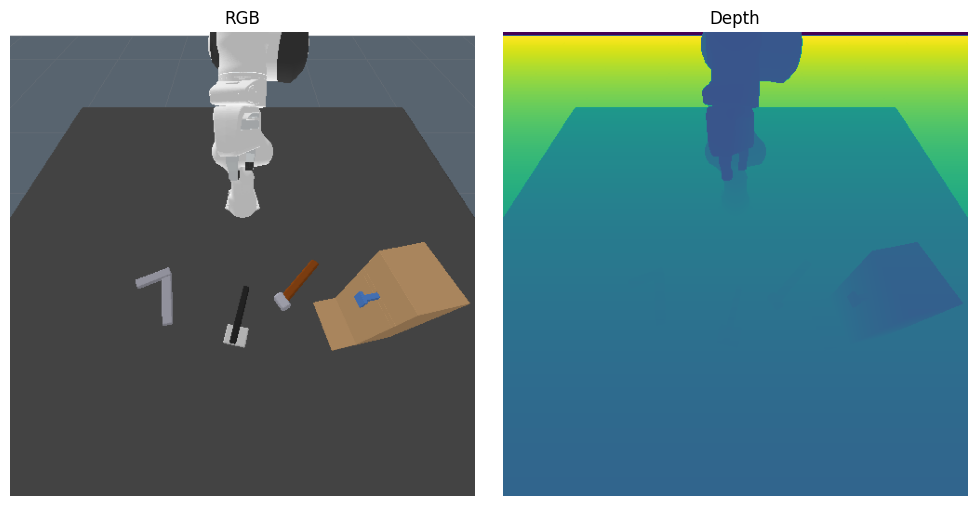


Trial 0 | Calling OpenAI...
Asking for tool selection and all waypoints together...

Final predicted data:
{
  "selected_tool": "hammer",
  "selection_reasoning": "The hammer has a dense head with a flat striking face, which is best suited to deliver direct horizontal force to the blue nail head. Its shape allows a clean, stable impact without slipping off the nail's axis.",
  "tool_waypoint": {
    "camera_uv": [
      318,
      291
    ]
  },
  "initial_waypoint": {
    "camera_uv": [
      377,
      289
    ]
  },
  "goal_waypoint": {
    "camera_uv": [
      402,
      289
    ]
  }
}


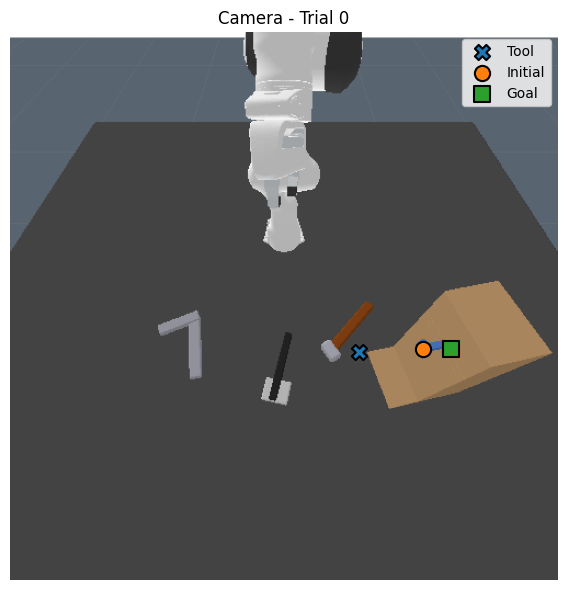

Saved: test_runs/2026-04-14_16-35-37/trial_000_waypoints.png
pcl size main: (500, 500, 3)
(500, 500, 3)
point:  [0.27227825 0.16416779 1.00102305]
camera position: [0.  0.7 1.6]
camera rotation matrix:
 [[-1.00000000e+00 -1.22464680e-16  0.00000000e+00]
 [-1.06057524e-16  8.66025404e-01 -5.00000000e-01]
 [ 6.12323400e-17 -5.00000000e-01 -8.66025404e-01]]
(500, 500, 3)
point:  [0.27227825 0.16416779 1.00102305]
tool point world: [-0.26785989  0.34747686  0.66640449]
initial point world: [-0.36752136  0.43600678  0.91702855]
goal point world: [-0.43986808  0.43600678  0.91702855]
selected tool: hammer
selected tool by point cloud:  hammer
selected tool base:  hammer-base
I added the joint to the base.
Grasp Score: 0.0
Task Score: 0.3462289569534581
All Score: 0.3462289569534581

 VLM vs. Spatial Point Cloud Evaluation Results

--- Total Selections ---
VLM Text Predictions:
  - hammer: 1
  - L-ruler: 0
  - spatula: 0

Spatial Point Cloud Corrections:
  - hammer: 1
  - L-ruler: 0
  - spatu

In [12]:
run_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
save_dir = Path("test_runs") / run_time
save_dir.mkdir(parents=True, exist_ok=True)

print("Saving to:", save_dir)
trial = 0

evaluation_stats = {
    "vlm_selected": {"hammer": 0, "L-ruler": 0, "spatula": 0},
    "pc_selected": {"hammer": 0, "L-ruler": 0, "spatula": 0},
    "total_mismatches": 0,
    "mismatch_log": []  # To store the exact details of what went wrong
}

while trial < parameters["num-trials"]:
    try:
        environment = GenerateEnvironment(parameters)
        environment.generate_environment()
        environment.C.delFrame("pcl")
        environment.C.view()
        
        # print(environment.C.getFrameNames())
        # cam = ry.CameraView(environment.C)
        # cam.setCamera("camera5")
        # print(cam.getFxycxy())
        # print(environment.C.getFrame('l_panda_base').getPosition())
        # print(environment.C.getFrame('camera5').getPosition())
        # print(environment.C.getFrame('camera5').getRotationMatrix())
        # raise Exception
    

        rgb_images, depth_images, pcls = mutils.get_rgb_images(environment.C, parameters["cameras"], environment.C.getFrame("camera5"))
        # f = environment.C.addFrame('pcl', 'world')
        # f.setPointCloud(points= pcls[0], colors = [0,0,255])
        print("RGB shape:", rgb_images[0].shape)
        print("Depth shape:", depth_images[0].  shape )
        print("Point cloud shape:", pcls[0      ].shape)
        draw_rgb_and_depth(rgb_images[0], depth_images[0])
        environment.C.view()

        

        image_bytes = numpy_to_bytes(rgb_images[0], (500, 500))

        if parameters["task"] == "minigolf":
            task_name = "Precision Minigolf: Tool-Assisted Ball Striking"
            # task_description = "Use the tool to push the ball into the hole on the platform."
            task_description = "The objective is to use a tool to perform a controlled push of a blue spherical ball into a white target hole located on a raised black rectangular platform."
        elif parameters["task"] == "lifting":
            task_description = "The objective is to use a tool to securely lift a blue cylindrical stick from its starting position on the target platform. The robot must wedge or slide the tool under the stick to ensure a stable upward relocation."
            task_name = "Tool-Assisted Stable Lifting"
        elif parameters["task"] == "hammering":
            task_name = "Precision Hammering: Tool-Assisted Nail Insertion"
            task_description = "The objective is to use a tool to strike or push a blue horizontal nail into its target slot on the brown vertical platform. The robot must align the tool's striking surface with the head of the nail and apply direct horizontal force to drive the nail into the wall."
        else:
            raise Exception("Unknown task")
        

        print(f"\nTrial {trial} | Calling OpenAI...")


        print("Asking for tool selection and all waypoints together...")

        raw_resp = ask_openai_with_image(
            get_prompt_detailed(parameters["task"], task_description),
            image_bytes
        )

        final_predicted_data = extract_json(raw_resp)

        print("\nFinal predicted data:")
        print(json.dumps(final_predicted_data, indent=2))

        visualize_predicted_waypoints(
            rgb_images,
            final_predicted_data,
            trial,
            save_dir,
            vlm_size=500
            )
        print(f"pcl size main: {pcls[0].shape}")
        tool_point = get_point_from_pcl(final_predicted_data, pcls, "tool_waypoint")
        # lifting_obj = environment.C.getFrame("lifting-obj").getPosition()
        # init_point = get_world_from_pixel(environment, final_predicted_data["initial_waypoint"]["camera_uv"], lifting_obj[2] - 0.1)
        # goal_point = get_world_from_pixel(environment, final_predicted_data["goal_waypoint"]["camera_uv"], lifting_obj[2] + 0.1)
        # init_point = get_point_from_pcl(final_predicted_data, pcls, "initial_waypoint")
        # goal_point = get_point_from_pcl(final_predicted_data, pcls, "goal_waypoint")

        # print("tool point:", tool_point)
        # print("init point:", init_point)
        # print("goal point:", goal_point)

        cam_frame = environment.C.getFrame("camera5")
        print("camera position:", cam_frame.getPosition())
        print("camera rotation matrix:\n", cam_frame.getRotationMatrix())

        # ball_frame = environment.C.getFrame("minigolf-obj")
        # print("ball world position:", ball_frame.getPosition())

        tool_point_cam, tool_point_world = get_world_point(final_predicted_data, pcls, cam_frame, "tool_waypoint")
        selected_tool_pc = find_selected_tool_by_pc(environment, tool_point_world)

        # tool_point_cam, tool_point_world = get_world_point(final_predicted_data, pcls, cam_frame, "tool_waypoint")
        tool_point_world = get_world_from_pixel(environment, final_predicted_data["tool_waypoint"]["camera_uv"], environment.C.getFrame(selected_tool_pc+"-base").getPosition()[2])

    
        init_point_world = get_world_from_pixel_for_hammering(environment, final_predicted_data["initial_waypoint"]["camera_uv"], "hammering-obj")
        goal_point_world = get_world_from_pixel_for_hammering(environment, final_predicted_data["goal_waypoint"]["camera_uv"], "hammering-obj")
        
        # init_point_world = get_world_from_pixel(environment, final_predicted_data["initial_waypoint"]["camera_uv"], init_target)
        # goal_point_world = get_world_from_pixel(environment, final_predicted_data["goal_waypoint"]["camera_uv"], goal_target)
        # init_point_cam, init_point_world = get_world_point(final_predicted_data, pcls, cam_frame, "initial_waypoint")
        # goal_point_cam, goal_point_world = get_world_point(final_predicted_data, pcls, cam_frame, "goal_waypoint")

       
        # print("tool point camera:", tool_point_cam)
        print("tool point world:", tool_point_world)

        # print("initial point camera:", init_point_cam)
        print("initial point world:", init_point_world)

        # print("goal point camera:", goal_point_cam)
        print("goal point world:", goal_point_world)

        print("selected tool:", final_predicted_data["selected_tool"])


        
        # print(f"Selected tool center: {environment.C.getFrame(best_tool + '-head').getPosition()}")
        # print(f"Selected tool center: {tool_point_world}")
        # 
        if final_predicted_data["selected_tool"] == "hammer":
            tool_label = 3
        elif final_predicted_data["selected_tool"] == "spatula":
            tool_label = 4
        elif final_predicted_data["selected_tool"] == "L-ruler":
            tool_label = 5
        
        tool_mask = np.isin(environment.point_clouds_labels[:,3], tool_label)
        tool_pc = environment.point_clouds_labels[tool_mask]
        f = environment.C.addFrame('tool-pcl', 'world')
        f.setPointCloud(points= tool_pc[:,:3], colors = [0,0,255])
        environment.C.view()

        # grasp_position = mutils.post_posititon(tool_pc[:,:3], tool_point_world)
        grasp_position = tool_point_world   
        selected_tool_pc = find_selected_tool_by_pc(environment, tool_point_world)
        print("selected tool by point cloud: ", selected_tool_pc)
        selected_tool_base = selected_tool_pc + "-base"
        print("selected tool base: ", selected_tool_base)

        grasp_position[2] = environment.C.getFrame(selected_tool_pc+'-base').getPosition()[2] - 0.01
        # init_point_world[2] = init_point_world[2] - 0.1
        # goal_point_world[2] = environment.C.getFrame("lifting-obj").getPosition()[2]
        
        
        # if environment.C.getFrame("lifting-obj").getPosition()[0] < 0: 
        #     init_point_world[0] = init_point_world[0] + 0.15
        # else: 
        #     init_point_world[0] = init_point_world[0] - 0.15


        environment.C.addFrame("tool-waypoint") \
            .setShape(ry.ST.marker, [0.1]) \
            .setPosition(grasp_position)

        environment.C.addFrame("initial-waypoint") \
            .setShape(ry.ST.marker, [0.1]) \
            .setPosition(init_point_world)

        environment.C.addFrame("goal-waypoint") \
            .setShape(ry.ST.marker, [0.1]) \
            .setPosition(goal_point_world)
        
        environment.C.view()

        best_tool = final_predicted_data["selected_tool"]
        selected_part = mutils.find_grasping_part(
                environment.C,
                selected_tool_pc,
                tool_point_world
            )
        other_tools = [item for item in environment.tool_objs if item != selected_tool_pc]
        mutils.reparent_tool(environment.C, best_tool, selected_part, other_tools)

        

        environment.C.getFrame("tool-waypoint").setQuaternion(environment.C.getFrame(selected_part).getQuaternion())
        # environment.C.getFrame("initial-waypoint").setQuaternion(environment.C.getFrame(selected_part).getQuaternion())
        # environment.C.getFrame("goal-waypoint").setQuaternion(environment.C.getFrame(selected_part).getQuaternion())
        
        environment.C.getFrame("initial-waypoint").setQuaternion(mutils.rotate_quat_yaw_angle(environment.C.getFrame("nail-base").getQuaternion(),0))
        environment.C.getFrame("goal-waypoint").setQuaternion(mutils.rotate_quat_yaw_angle(environment.C.getFrame("nail-base").getQuaternion(),0))

        mutils.ManipulationWithKOMO_hammering(environment.C, best_tool, environment.env)


        vlm_tool = final_predicted_data["selected_tool"]
        pc_tool = selected_tool_pc

        if vlm_tool in evaluation_stats["vlm_selected"]:
            evaluation_stats["vlm_selected"][vlm_tool] += 1
        else:
            print("Unknown VLM tool:", vlm_tool)

        if pc_tool in evaluation_stats["pc_selected"]:
            evaluation_stats["pc_selected"][pc_tool] += 1

        # 4. Check for and log any mismatches
        if vlm_tool != pc_tool:
            evaluation_stats["total_mismatches"] += 1
            evaluation_stats["mismatch_log"].append({
                "vlm_text_prediction": vlm_tool,
                "pc_spatial_correction": pc_tool
            })


        trial += 1

    except PlacementError as e:
        print("PlacementError:", e)
        print("Retrying trial...")
    except Exception as e:
        print("Exception occurred:")
        traceback.print_exc()
        break
    
print("\n" + "="*50)
print(" VLM vs. Spatial Point Cloud Evaluation Results")
print("="*50)

# Print the overall counts
print("\n--- Total Selections ---")
print("VLM Text Predictions:")
for tool, count in evaluation_stats["vlm_selected"].items():
    print(f"  - {tool}: {count}")

print("\nSpatial Point Cloud Corrections:")
for tool, count in evaluation_stats["pc_selected"].items():
    print(f"  - {tool}: {count}")

# Print the mismatch details
print("\n--- Mismatch Summary ---")
print(f"Total Mismatches: {evaluation_stats['total_mismatches']}")

if evaluation_stats["total_mismatches"] > 0:
    print("\nDetailed Mismatch Log:")
    for idx, mismatch in enumerate(evaluation_stats["mismatch_log"], 1):
        print(f"  {idx}. VLM selected '{mismatch['vlm_text_prediction']}', "
              f"but the spatial waypoint was closest to '{mismatch['pc_spatial_correction']}'.")
else:
    print("\nNo mismatches found! The VLM text and spatial waypoints aligned perfectly.")

print("="*50 + "\n")

In [13]:
environment.C.view()

0